In [1]:
# Define the file path to the plots directory
plots_dir <- "plots"

# Create the plots folder if it doesn't exist
if (!dir.exists(plots_dir)) {
  dir.create(plots_dir)
}

# Define the file path to the results directory
results_dir <- "results"

# Create the results folder if it doesn't exist
if (!dir.exists(results_dir)) {
  dir.create(results_dir)
}

In [2]:
# Define the file path to the data directory
# Replace with the path of the folder the files will be in
data_dir <- file.path("data", "SRP140558")

# Declare the file path to the gene expression matrix file
# inside directory saved as `data_dir`
# Replace with the path to your dataset file
data_file <- file.path(data_dir, "SRP140558.tsv")

# Declare the file path to the metadata file
# inside the directory saved as `data_dir`
# Replace with the path to your metadata file
metadata_file <- file.path(data_dir, "metadata_SRP140558.tsv")

In [3]:
# Check if the gene expression matrix file is at the path stored in `data_file`
file.exists(data_file)

# Check if the metadata file is at the file path stored in `metadata_file`
file.exists(metadata_file)

[1] TRUE

[1] TRUE

In [4]:
library(tidyverse)
library(devtools)
library(BiocManager)
library(TCGAbiolinks)
library(DESeq2)
library(WGCNA)
library(impute)
library(limma)
library(ggforce)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v ggplot2   3.5.2     v tibble    3.2.1
v lubridate 1.9.3     v tidyr     1.3.1
v purrr     1.0.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Lade nötiges Paket: usethis

Bioconductor version '3.14' is out-of-date; the current release version '3.21'
  is available with R version '4.5'; see https://bioconductor.org/install


Attache Paket: 'BiocManager'


Das folgende Objekt ist maskiert 'package:devtools':

    install


Lade nötiges Paket: S4Vectors

Lade nötiges Paket: stats4

Lade nötiges Paket: BiocGenerics


Attache Paket: 'BiocGenerics'


Die folgenden Objekte sind maskiert von 'package:lubridate':

    i

In [5]:
# Read in metadata TSV file
metadata <- readr::read_tsv(metadata_file)
head(metadata)
# Read in data TSV file
df <- readr::read_tsv(data_file) %>%
  # Here we are going to store the gene IDs as row names so 
  #that we can have a numeric matrix to perform calculations on later
  tibble::column_to_rownames("Gene")
head(df)

Rows: 62 Columns: 24
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr  (9): refinebio_accession_code, experiment_accession, refinebio_organism...
dbl  (1): refinebio_processor_id
lgl (14): refinebio_age, refinebio_cell_line, refinebio_compound, refinebio_...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


refinebio_accession_code,experiment_accession,refinebio_age,refinebio_cell_line,refinebio_compound,refinebio_developmental_stage,refinebio_disease,refinebio_disease_stage,refinebio_genetic_information,refinebio_organism,...,refinebio_processor_version,refinebio_race,refinebio_sex,refinebio_source_archive_url,refinebio_source_database,refinebio_specimen_part,refinebio_subject,refinebio_time,refinebio_title,refinebio_treatment
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<chr>,...,<chr>,<lgl>,<lgl>,<lgl>,<chr>,<lgl>,<chr>,<lgl>,<chr>,<lgl>
SRR7011789,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,v1.20.0,NA,NA,NA,SRA,NA,subject_006,NA,AVB_006_AV_PBMC,NA
SRR7011790,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,v1.20.0,NA,NA,NA,SRA,NA,subject_006,NA,AVB_006_CV_PBMC,NA
SRR7011791,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,v1.20.0,NA,NA,NA,SRA,NA,subject_007,NA,AVB_007_AV_PBMC,NA
SRR7011792,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,v1.20.0,NA,NA,NA,SRA,NA,subject_007,NA,AVB_007_CV_PBMC,NA
SRR7011793,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,v1.20.0,NA,NA,NA,SRA,NA,subject_012,NA,AVB_012_AV_PBMC,NA
SRR7011794,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,v1.20.0,NA,NA,NA,SRA,NA,subject_012,NA,AVB_012_CV_PBMC,NA


Rows: 43363 Columns: 63
-- Column specification --------------------------------------------------------
Delimiter: "\t"
chr  (1): Gene
dbl (62): SRR7011789, SRR7011790, SRR7011791, SRR7011792, SRR7011793, SRR701...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


,SRR7011789,SRR7011790,SRR7011791,SRR7011792,SRR7011793,SRR7011794,SRR7011795,SRR7011796,SRR7011797,SRR7011798,...,SRR7011841,SRR7011842,SRR7011843,SRR7011844,SRR7011845,SRR7011846,SRR7011847,SRR7011848,SRR7011849,SRR7011850
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000000003,15.99523,50.83783,28.48821,29.07569,52.23205,36.11115,43.35158,34.64439,33.43118,38.00533,...,30.59415,35.02736,9.372858,7.304499,28.44376,11.03754,21.26087,38.64671,16.56035,32.25159
ENSG00000000005,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
ENSG00000000419,502.05225,754.04900,915.45510,737.11370,745.99475,712.05440,845.95715,954.43730,776.92285,864.21710,...,622.07110,491.80786,644.084530,370.238100,544.56870,467.82172,439.46545,461.14920,360.14233,508.21650
ENSG00000000457,621.81780,334.10123,138.58366,456.39725,204.22348,202.14212,426.26400,184.33434,214.73816,182.25615,...,695.71160,983.41833,145.023250,696.024800,646.91370,490.20505,577.11774,746.87695,766.19010,650.12780
ENSG00000000460,236.88013,129.40700,77.20416,172.84923,50.01204,65.94781,145.59264,82.33605,115.86778,79.71537,...,291.49118,200.07272,99.361305,175.913270,278.09564,199.80666,168.56007,131.69302,272.46475,327.57574
ENSG00000000938,3936.67190,873.26060,3564.88040,2083.41430,1239.47810,840.29580,1444.13570,919.85864,2768.18730,823.46466,...,6907.83800,4363.97800,1472.551600,3545.336000,6079.77830,3147.84500,5491.98930,3937.33450,3060.66800,3302.92530


In [6]:
#Let's ensure that the metadata and data are in the same sample order.

# Make the data in the order of the metadata
df <- df %>%
  dplyr::select(metadata$refinebio_accession_code)

# Check if this is in the same order
all.equal(colnames(df), metadata$refinebio_accession_code)

[1] TRUE

In [7]:
# The next DESeq2 functions need the values to be converted to integers
df <- round(df) %>%
  # The next steps require a data frame and round() returns a matrix
  as.data.frame() %>%
  # Only keep rows that have total counts above the cutoff
  dplyr::filter(rowSums(.) >= 50)

head(df)

,SRR7011789,SRR7011790,SRR7011791,SRR7011792,SRR7011793,SRR7011794,SRR7011795,SRR7011796,SRR7011797,SRR7011798,...,SRR7011841,SRR7011842,SRR7011843,SRR7011844,SRR7011845,SRR7011846,SRR7011847,SRR7011848,SRR7011849,SRR7011850
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000000003,16,51,28,29,52,36,43,35,33,38,...,31,35,9,7,28,11,21,39,17,32
ENSG00000000419,502,754,915,737,746,712,846,954,777,864,...,622,492,644,370,545,468,439,461,360,508
ENSG00000000457,622,334,139,456,204,202,426,184,215,182,...,696,983,145,696,647,490,577,747,766,650
ENSG00000000460,237,129,77,173,50,66,146,82,116,80,...,291,200,99,176,278,200,169,132,272,328
ENSG00000000938,3937,873,3565,2083,1239,840,1444,920,2768,823,...,6908,4364,1473,3545,6080,3148,5492,3937,3061,3303
ENSG00000000971,61,29,14,27,8,27,40,5,35,6,...,28,37,20,12,53,17,56,28,46,57


In [8]:
metadata <- metadata %>%
  dplyr::mutate(
    time_point = dplyr::case_when(
      # Create our new variable based on refinebio_title containing AV/CV
      stringr::str_detect(refinebio_title, "_AV_") ~ "acute illness",
      stringr::str_detect(refinebio_title, "_CV_") ~ "recovering"
    ),
    # It's easier for future items if this is already set up as a factor
    time_point = as.factor(time_point)
  )
head(metadata)


refinebio_accession_code,experiment_accession,refinebio_age,refinebio_cell_line,refinebio_compound,refinebio_developmental_stage,refinebio_disease,refinebio_disease_stage,refinebio_genetic_information,refinebio_organism,...,refinebio_race,refinebio_sex,refinebio_source_archive_url,refinebio_source_database,refinebio_specimen_part,refinebio_subject,refinebio_time,refinebio_title,refinebio_treatment,time_point
<chr>,<chr>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<chr>,...,<lgl>,<lgl>,<lgl>,<chr>,<lgl>,<chr>,<lgl>,<chr>,<lgl>,<fct>
SRR7011789,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,NA,NA,NA,SRA,NA,subject_006,NA,AVB_006_AV_PBMC,NA,acute illness
SRR7011790,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,NA,NA,NA,SRA,NA,subject_006,NA,AVB_006_CV_PBMC,NA,recovering
SRR7011791,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,NA,NA,NA,SRA,NA,subject_007,NA,AVB_007_AV_PBMC,NA,acute illness
SRR7011792,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,NA,NA,NA,SRA,NA,subject_007,NA,AVB_007_CV_PBMC,NA,recovering
SRR7011793,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,NA,NA,NA,SRA,NA,subject_012,NA,AVB_012_AV_PBMC,NA,acute illness
SRR7011794,SRP140558,NA,NA,NA,NA,NA,NA,NA,HOMO_SAPIENS,...,NA,NA,NA,SRA,NA,subject_012,NA,AVB_012_CV_PBMC,NA,recovering


In [9]:
#levels(metadata$time_point)#
#str(df)
gsg <- goodSamplesGenes(t(df))
summary(gsg)

 Flagging genes and samples with too many missing values...
  ..step 1


            Length Class  Mode   
goodGenes   26873  -none- logical
goodSamples    62  -none- logical
allOK           1  -none- logical

In [10]:
df <- df[gsg$goodGenes == TRUE, ]
df

,SRR7011789,SRR7011790,SRR7011791,SRR7011792,SRR7011793,SRR7011794,SRR7011795,SRR7011796,SRR7011797,SRR7011798,...,SRR7011841,SRR7011842,SRR7011843,SRR7011844,SRR7011845,SRR7011846,SRR7011847,SRR7011848,SRR7011849,SRR7011850
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000000003,16,51,28,29,52,36,43,35,33,38,...,31,35,9,7,28,11,21,39,17,32
ENSG00000000419,502,754,915,737,746,712,846,954,777,864,...,622,492,644,370,545,468,439,461,360,508
ENSG00000000457,622,334,139,456,204,202,426,184,215,182,...,696,983,145,696,647,490,577,747,766,650
ENSG00000000460,237,129,77,173,50,66,146,82,116,80,...,291,200,99,176,278,200,169,132,272,328
ENSG00000000938,3937,873,3565,2083,1239,840,1444,920,2768,823,...,6908,4364,1473,3545,6080,3148,5492,3937,3061,3303
ENSG00000000971,61,29,14,27,8,27,40,5,35,6,...,28,37,20,12,53,17,56,28,46,57
ENSG00000001036,241,98,363,191,198,80,196,92,131,88,...,378,201,157,259,342,214,357,291,178,202
ENSG00000001084,621,846,1022,799,894,868,1420,867,919,686,...,718,814,505,458,561,717,702,586,503,846
ENSG00000001167,1603,1688,1002,1874,1265,1393,1445,1625,1122,1162,...,1486,1446,928,1316,1192,1190,1098,1252,1214,1344


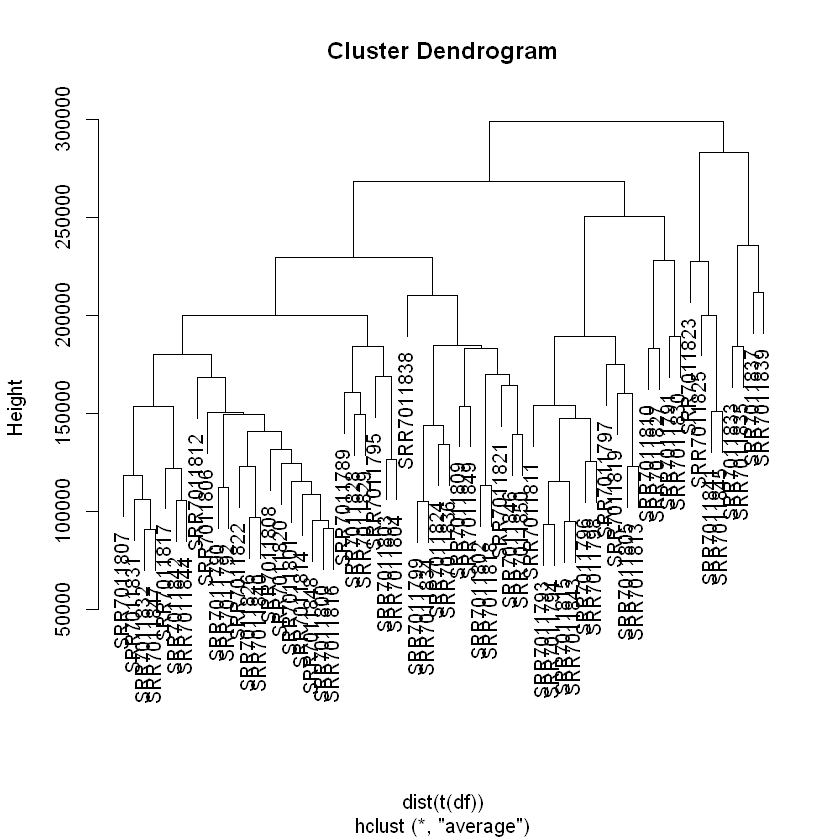

In [11]:
htree <- hclust(dist(t(df)), method = "average")
plot(htree)

In [12]:
# Create a `DESeqDataSet` object
dds <- DESeqDataSetFromMatrix(
  countData = df, # Our prepped data frame with counts
  colData = metadata, # Data frame with annotation for our samples
  design = ~1 # Here we are not specifying a model
)

converting counts to integer mode



In [13]:
#Normalize and transform the data in the `DESeqDataSet` object using the `vst()`
#function from the `DESEq2` R package
dds_norm <- vst(dds)
dds_norm

class: DESeqTransform 
dim: 26873 62 
metadata(1): version
assays(1): ''
rownames(26873): ENSG00000000003 ENSG00000000419 ... ENSG00000286271
  ENSG00000286272
rowData names(4): baseMean baseVar allZero dispFit
colnames(62): SRR7011789 SRR7011790 ... SRR7011849 SRR7011850
colData names(26): refinebio_accession_code experiment_accession ...
  time_point sizeFactor

In [14]:
normalized_counts <- t(assay(dds_norm))
#normalized_counts
nrow(normalized_counts)
ncol(normalized_counts)

[1] 62

[1] 26873

In [15]:
power <- c(c(1:10), seq(from = 12,to = 50,by = 2))
power

[1]  1  2  3  4  5  6  7  8  9 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40
[26] 42 44 46 48 50

In [16]:
stf <- pickSoftThreshold(normalized_counts,
                         powerVector = power,
                         networkType = "signed",
                         verbose = 5)
stf.data <- stf$fitIndices

pickSoftThreshold: will use block size 1664.
 pickSoftThreshold: calculating connectivity for given powers...
   ..working on genes 1 through 1664 of 26873


Warning message:
"executing %dopar% sequentially: no parallel backend registered"


   ..working on genes 1665 through 3328 of 26873
   ..working on genes 3329 through 4992 of 26873
   ..working on genes 4993 through 6656 of 26873
   ..working on genes 6657 through 8320 of 26873
   ..working on genes 8321 through 9984 of 26873
   ..working on genes 9985 through 11648 of 26873
   ..working on genes 11649 through 13312 of 26873
   ..working on genes 13313 through 14976 of 26873
   ..working on genes 14977 through 16640 of 26873
   ..working on genes 16641 through 18304 of 26873
   ..working on genes 18305 through 19968 of 26873
   ..working on genes 19969 through 21632 of 26873
   ..working on genes 21633 through 23296 of 26873
   ..working on genes 23297 through 24960 of 26873
   ..working on genes 24961 through 26624 of 26873
   ..working on genes 26625 through 26873 of 26873
   Power SFT.R.sq  slope truncated.R.sq  mean.k. median.k. max.k.
1      1   0.0491  42.50          0.947 13400.00  1.34e+04  13600
2      2   0.8530 -12.60          0.871  7230.00  7.08e+03   84

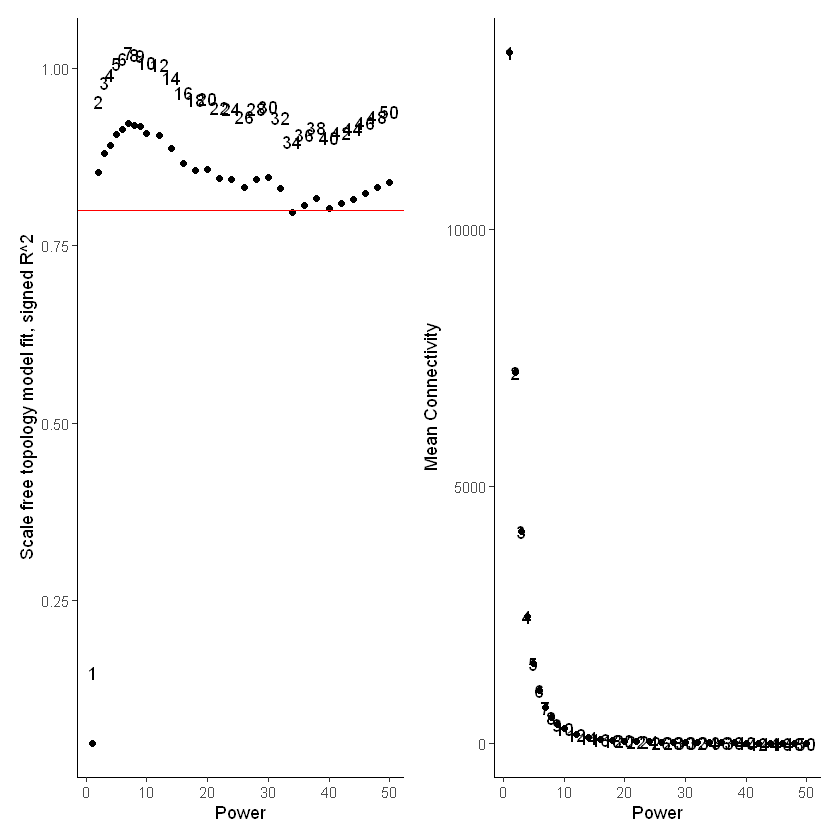

In [ ]:

a1 <- ggplot(stf_data, aes(Power, SFT.R.sq, label = Power)) +
  geom_point() +
  geom_text(nudge_y = 0.1) +
  geom_hline(yintercept = 0.8, color = "red") +
  labs(x = "Power", y = "Scale free topology model fit, signed R^2") +
  theme_classic()


a2 <- ggplot(stf_data, aes(Power, mean.k., label = Power)) +
  geom_point() +
  geom_text(nudge_y = 0.1) +
  labs(x = "Power", y = "Mean_Connectivity") +
  theme_classic()
library(patchwork)
a1 + a2

In [18]:
normalized_counts [] <- sapply(normalized_counts, as.numeric)
soft_power <- 7
temp_cor <- cor
cor <- WGCNA::cor

In [19]:
bwnet <- blockwiseModules(datExpr = normalized_counts,
                          maxBlockSize = ncol(normalized_counts),
                          TOMType = "signed",
                          mergeCutHeight = 0.25,
                          numericLabels = TRUE,
                          randomSeed = 1234,
                          verbose = 3)

 Calculating module eigengenes block-wise from all genes
   Flagging genes and samples with too many missing values...
    ..step 1
 ..Working on block 1 .
    TOM calculation: adjacency..
    ..will not use multithreading.
     Fraction of slow calculations: 0.000000
    ..connectivity..
    ..matrix multiplication (system BLAS)..
    ..normalization..
    ..done.
 ....clustering..
 ....detecting modules..
 ....calculating module eigengenes..
 ....checking kME in modules..
     ..removing 2299 genes from module 1 because their KME is too low.
     ..removing 208 genes from module 2 because their KME is too low.
     ..removing 120 genes from module 3 because their KME is too low.
     ..removing 22 genes from module 4 because their KME is too low.
     ..removing 19 genes from module 5 because their KME is too low.
     ..removing 1 genes from module 7 because their KME is too low.
     ..removing 1 genes from module 8 because their KME is too low.
     ..removing 6 genes from module 

In [20]:
length(bwnet$dendrograms[[1]]$order)         # number of leaves in dendrogram
length(bwnet$unmergedColors)                 # should match the above
length(bwnet$colors)                         # should match the above



[1] 26873

[1] 26873

[1] 26873

Warning message in graphics:::plotHclust(n1, merge, height, order(x$order), hang, :
""dendrolabels" ist kein Grafikparameter"
Warning message in graphics:::plotHclust(n1, merge, height, order(x$order), hang, :
""dendrolabels" ist kein Grafikparameter"
Warning message in axis(2, at = pretty(range(height)), ...):
""dendrolabels" ist kein Grafikparameter"
Warning message in title(main = main, sub = sub, xlab = xlab, ylab = ylab, ...):
""dendrolabels" ist kein Grafikparameter"


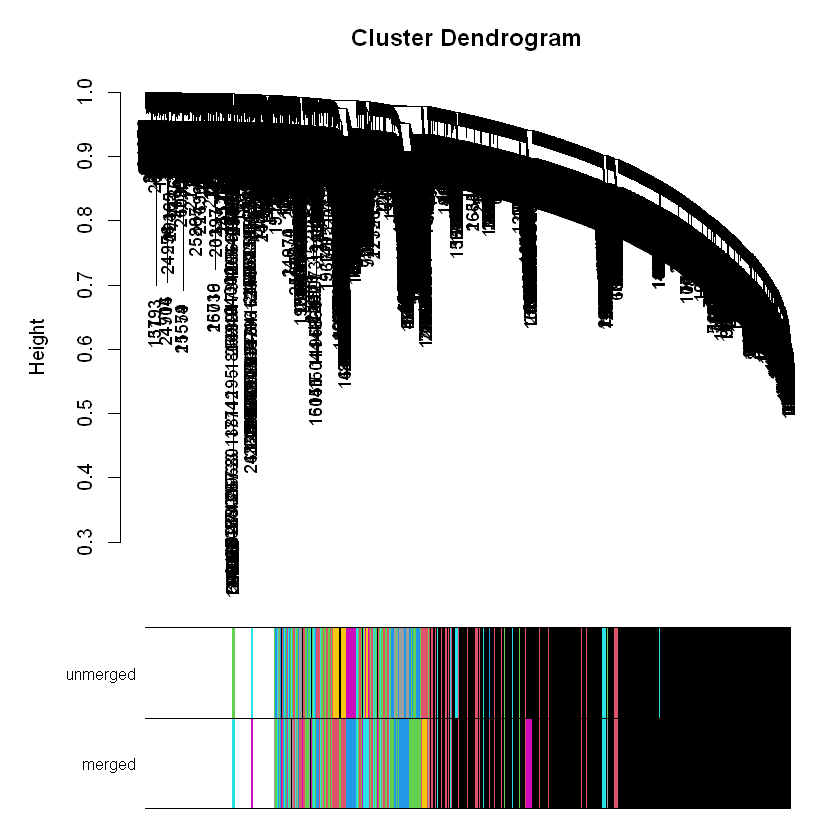

In [21]:
plotDendroAndColors(bwnet$dendrograms[[1]],
                    cbind(bwnet$unmergedColors,bwnet$colors),
                    c("unmerged","merged"),
                    dendrolabels = FALSE,
                    hang = 0.03,
                    guideHang = 0.05)

In [22]:
readr::write_rds(bwnet,
  file = file.path("results", "SRP140558_wgcna_results.RDS")
)

In [23]:
module_eigengenes <- bwnet$MEs
head(module_eigengenes)

,ME2,ME14,ME5,ME10,ME11,ME3,ME4,ME13,ME12,ME6,ME7,ME8,ME1,ME9,ME0
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SRR7011789,-0.06633181,-0.03876316,0.18823290,-0.10311259,0.1985400,-0.03049480,-0.01873473,-0.16478231,-0.052349655,0.004357618,-0.09009067,0.25899630,0.03925088,-0.03164083,0.0003231334
SRR7011790,0.18578873,-0.04842007,0.15881110,-0.18454529,-0.1438508,-0.13349540,-0.26446190,-0.17187285,-0.157864567,-0.141277663,-0.14572068,-0.02356773,-0.05634476,0.17308004,0.1487789971
SRR7011791,0.02760853,-0.01170573,0.17262759,0.37084215,-0.1255913,0.34264231,0.20195592,0.09178410,-0.004218395,-0.076179315,-0.04987709,-0.29892501,-0.21044682,-0.19912419,-0.1445556609
SRR7011792,0.04310844,-0.05117870,0.17515465,-0.05398224,-0.1156757,-0.08911999,-0.12090181,0.10681712,0.073607198,-0.064532154,-0.14039921,-0.12540667,0.04137421,0.14161529,-0.0374827649
SRR7011793,0.19823473,-0.01478432,0.07728213,-0.11245659,0.1078138,0.03835131,-0.12247602,0.07859544,-0.194371856,-0.161711367,-0.09742868,-0.01892435,-0.18307646,0.01307931,0.1663276593
SRR7011794,0.27449110,-0.01519526,0.14570067,-0.13549324,-0.1264649,-0.03044569,-0.21060015,0.07927482,-0.199673223,-0.192203195,-0.13892359,0.02428617,-0.20721834,0.02965133,0.1498734373


In [24]:
#We can also see if our eigengenes relate to our metadata labels. 
#First we double check that our samples are still in order.

all.equal(metadata$refinebio_accession_code, rownames(module_eigengenes))

[1] TRUE

In [25]:
# Create the design matrix from the `time_point` variable
des_mat <- model.matrix(~ metadata$time_point)

In [26]:
# lmFit() needs a transposed version of the matrix
fit <- limma::lmFit(t(module_eigengenes), design = des_mat)

# Apply empirical Bayes to smooth standard errors
fit <- limma::eBayes(fit)

In [27]:
# Apply multiple testing correction and obtain stats
stats_df <- limma::topTable(fit, number = ncol(module_eigengenes)) %>%
  tibble::rownames_to_column("module")

Removing intercept from test coefficients



In [28]:
stats_df

module,logFC,AveExpr,t,P.Value,adj.P.Val,B
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ME9,0.132759343,-9.974660e-18,4.20336037,2.892261e-05,0.0004338392,2.1825824
ME7,-0.107253959,3.819190e-18,-3.39582158,7.141727e-04,0.0043384342,-0.8065157
ME11,-0.105537209,-3.766728e-18,-3.34146668,8.676868e-04,0.0043384342,-0.9848906
ME3,-0.096837588,-8.513610e-18,-3.06602360,2.234049e-03,0.0083776820,-1.8445567
ME1,0.076900497,-1.755708e-18,2.43478533,1.509402e-02,0.0452820459,-3.5358923
ME10,-0.064801829,-1.796278e-17,-2.05172332,4.048546e-02,0.1012136577,-4.3730120
ME4,-0.055840717,-2.979807e-18,-1.76800104,7.739949e-02,0.1453121053,-4.9008922
ME8,0.055821790,1.641517e-17,1.76740179,7.749979e-02,0.1453121053,-4.9019242
ME0,0.046663851,1.085951e-18,1.47744767,1.399055e-01,0.2331758507,-5.3602072


In [31]:
module_9_df <- module_eigengenes %>%
  tibble::rownames_to_column("accession_code") %>%
  # Here we are performing an inner join with a subset of metadata
  dplyr::inner_join(metadata %>%
    dplyr::select(refinebio_accession_code, time_point),
  by = c("accession_code" = "refinebio_accession_code")
  )

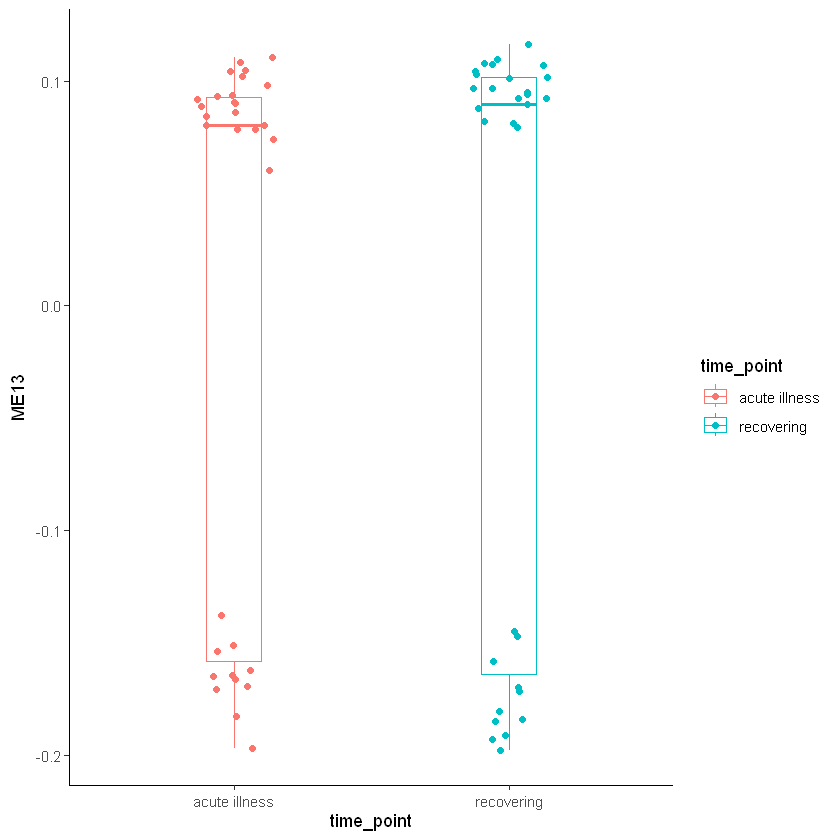

In [38]:
ggplot(
  module_9_df,
  aes(
    x = time_point,
    y = ME13,
    color = time_point
  )
) +
  # a boxplot with outlier points hidden (they will be in the sina plot)
  geom_boxplot(width = 0.2, outlier.shape = NA) +
  # A sina plot to show all of the individual data points
  ggforce::geom_sina(maxwidth = 0.3) +
  theme_classic()